                       open    high     low   close  volume  n_trades
timestamp                                                            
2010-01-01 00:00:00  100.05  100.05  100.05  100.05    25.0         1
2010-01-01 00:01:00  100.01  100.01  100.00  100.00    27.0         2
2010-01-01 00:02:00  100.05  100.10  100.05  100.10   101.0         5
2010-01-01 00:03:00  100.10  100.10  100.10  100.10    31.0         1
2010-01-01 00:04:00  100.10  100.10  100.10  100.10     0.0         0
...                     ...     ...     ...     ...     ...       ...
2010-01-04 11:15:00  102.36  102.36  102.36  102.36    42.0         1
2010-01-04 11:16:00  102.36  102.36  102.36  102.36     0.0         0
2010-01-04 11:17:00  102.39  102.39  102.36  102.36    19.0         3
2010-01-04 11:18:00  102.36  102.36  102.36  102.36    15.0         1
2010-01-04 11:19:00  102.39  102.40  102.39  102.40    19.0         4

[5000 rows x 6 columns]
0


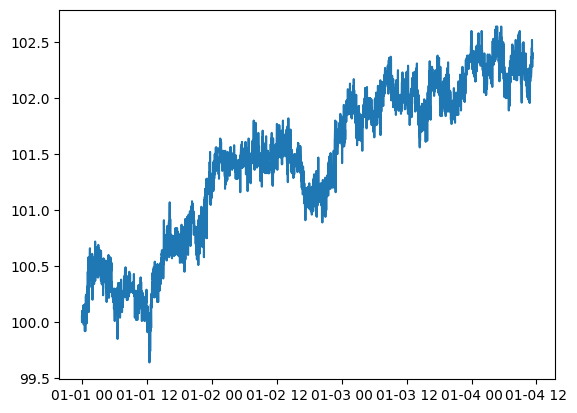

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from participants import simulate, prepare_data

# Run the simulation and prepare the data
n = 50_000
timestamped_data = simulate(decisions=n, seed=1)
ohlcv = prepare_data(timestamped_data, verbose=True)
plt.plot(ohlcv["close"])
plt.show()
ohlcv = ohlcv.reset_index()

In [125]:
X = ohlcv

# Create the target y and shift it by -1 minute.
# The target is the next minutes return direction
X['y'] = ohlcv['close'].pct_change(1).shift(-1) > 0
X['y'] = X['y'].replace({True: 1, False: 0})

# Remove the created nan
X = X.dropna()

# Separate the features and target
# use X[['y']] to avoid conversion to Series
y = X[['y']] 
# Also remove timestamp because model cannot handle datetime input
X = X[[x for x in X.columns if x not in ['y', 'timestamp']]]
X, y

C:\Users\luca\AppData\Local\Temp\ipykernel_15684\3757803045.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['y'] = X['y'].replace({True: 1, False: 0})


(        open    high     low   close  volume  n_trades
 0     100.05  100.05  100.05  100.05    25.0         1
 1     100.01  100.01  100.00  100.00    27.0         2
 2     100.05  100.10  100.05  100.10   101.0         5
 3     100.10  100.10  100.10  100.10    31.0         1
 4     100.10  100.10  100.10  100.10     0.0         0
 ...      ...     ...     ...     ...     ...       ...
 4995  102.36  102.36  102.36  102.36    42.0         1
 4996  102.36  102.36  102.36  102.36     0.0         0
 4997  102.39  102.39  102.36  102.36    19.0         3
 4998  102.36  102.36  102.36  102.36    15.0         1
 4999  102.39  102.40  102.39  102.40    19.0         4
 
 [5000 rows x 6 columns],
       y
 0     0
 1     1
 2     0
 3     0
 4     0
 ...  ..
 4995  0
 4996  0
 4997  0
 4998  1
 4999  0
 
 [5000 rows x 1 columns])

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import xgboost as xgb

def run_model(choice="XGB"):
    # Initialize the Time Series cross-validator
    # Train size is expanding and 
    # Test size by default is n_samples // (n_splits + 1)
    tscv = TimeSeriesSplit(n_splits=5)

    scores = []

    # Use enumerate(..., 1) to make i start at 1
    for i, (train_index, test_index) in enumerate(tscv.split(X), 1):

        # Select the relevant indices using .iloc
        X_train = X.iloc[train_index] 
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        # Scale the feature data
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Set the model
        if choice == "XGB":
            model = xgb.XGBClassifier(n_estimators=300, max_depth=3, seed=10)
        elif choice == "LR":
            model = LogisticRegression(random_state=10)
        elif choice == "RF":
            model = RandomForestClassifier(n_estimators=300, max_depth=3, random_state=10)
        else:
            raise ValueError(f"Unknown model choice: {choice}")
        
        # Train the model
        # values.ravel() is needed to avoid a warning
        model.fit(X_train, y_train.values.ravel())

        # Create the predictions. Slice to get the predictions for 1 (True)
        predicted_probabilities = model.predict_proba(X_test)[:, 1]
        # predicted_outcome = model.predict(X_test)

        # Evaluate
        roc_auc_test = roc_auc_score(y_test, predicted_probabilities)
        scores.append(roc_auc_test)
    
    return scores

model_scores = {}
for i in ["XGB", "LR", "RF"]:
    model_scores[i] = run_model(choice=i)

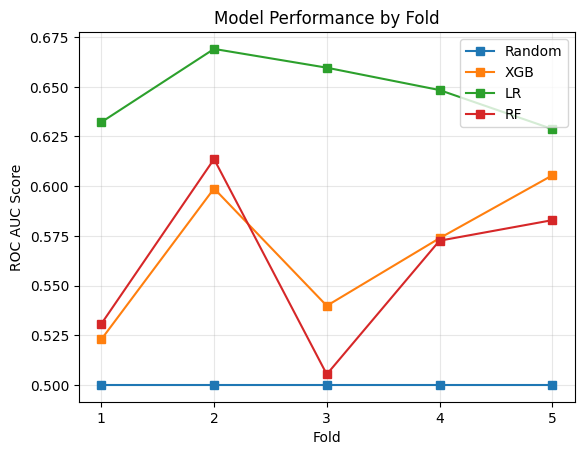

In [123]:
model_scores_df = pd.DataFrame(model_scores)
model_scores_df['Random'] = [0.5] * 5
model_scores_df['fold'] = model_scores_df.index + 1

# Plot the model scores
for model in ["Random", "XGB", "LR", "RF"]:
    plt.plot(
        model_scores_df["fold"],
        model_scores_df[model],
        marker="s", label=model
    )

plt.xlabel("Fold")
plt.ylabel("ROC AUC Score")
plt.title("Model Performance by Fold")
plt.xticks(model_scores_df["fold"])
plt.grid(alpha=0.3)
plt.legend()
plt.show()

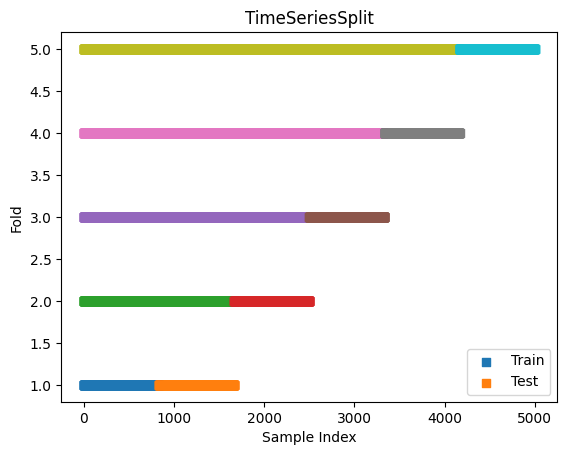

In [ ]:
# Visualize the selected data
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    plt.scatter(train_idx, [fold] * len(train_idx), label="Train" if fold == 1 else "", marker="s")
    plt.scatter(test_idx, [fold] * len(test_idx), label="Test" if fold == 1 else "", marker="s")

plt.xlabel("Sample Index")
plt.ylabel("Fold")
plt.title("TimeSeriesSplit")
plt.legend()
plt.show()